In [16]:
from datetime import datetime
import numpy as np
from cpuinfo import get_cpu_info
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map

In [17]:
vis=VisualTool(show=True, size=(10,10), save=True, dpi=100, save_dir="__RESULTS__/_plots")

### Overview of Construction site map

In [18]:
map=MapLoader().load("gangjin/full")

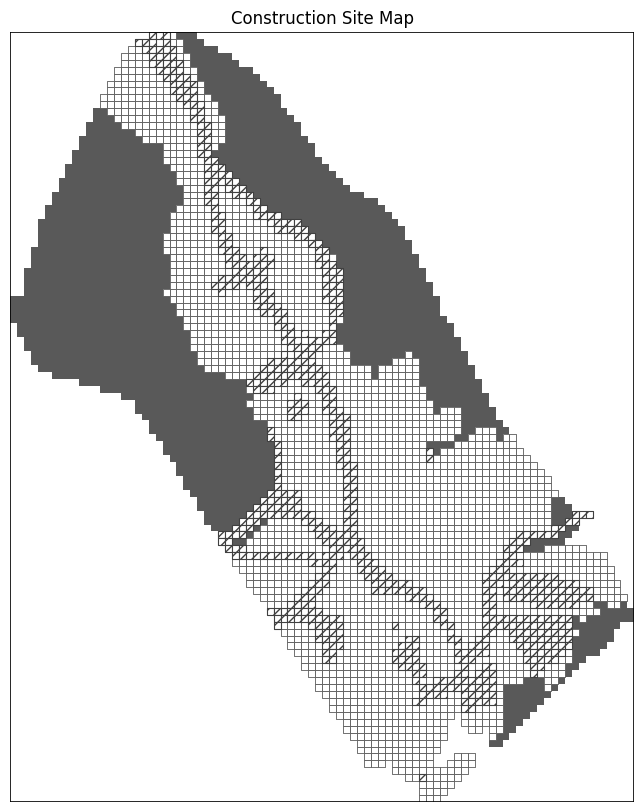

Saved figure: __RESULTS__/_plots/06-11-11-19/construction_map.png


In [19]:
vis.showMap(map_data=map, title="Construction Site Map", cmap='gray', filename="construction_map")

Installable map
<br><sub> A binary grid mask that defines physically feasible sensor deployment locations on the site. </sub>

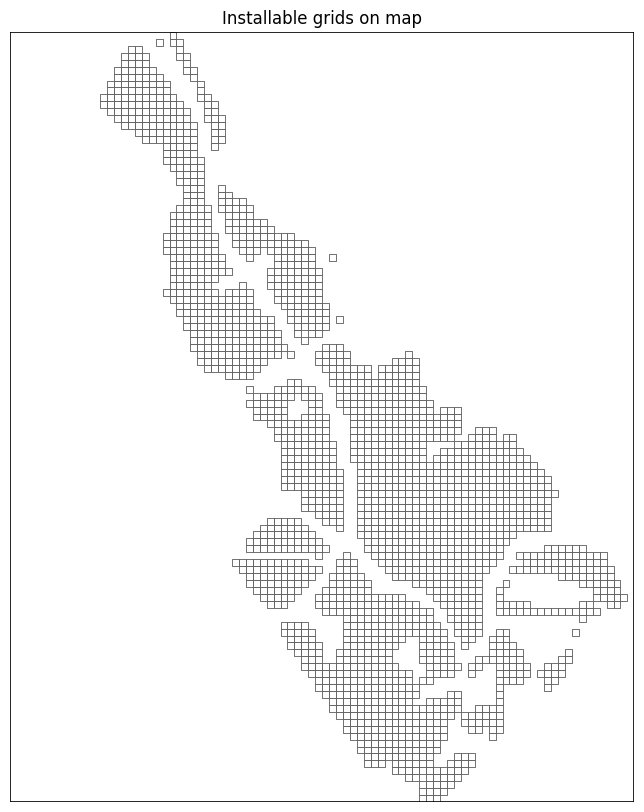

Saved figure: __RESULTS__/_plots/06-11-11-19/installable_map.png


In [20]:
installable_layer = layer_map(map, keep_values=[2])
vis.showMap(map_data=installable_layer, title="Installable grids on map", cmap='jet', filename="installable_map", zone_style="installable")

Uninstallable map
<br><sub>Regions excluded from sensor deployment due to safety, accessibility, or operational constraints <br>(e.g., equipment routes, waterlogged areas, vegetation, and offices).</sub>

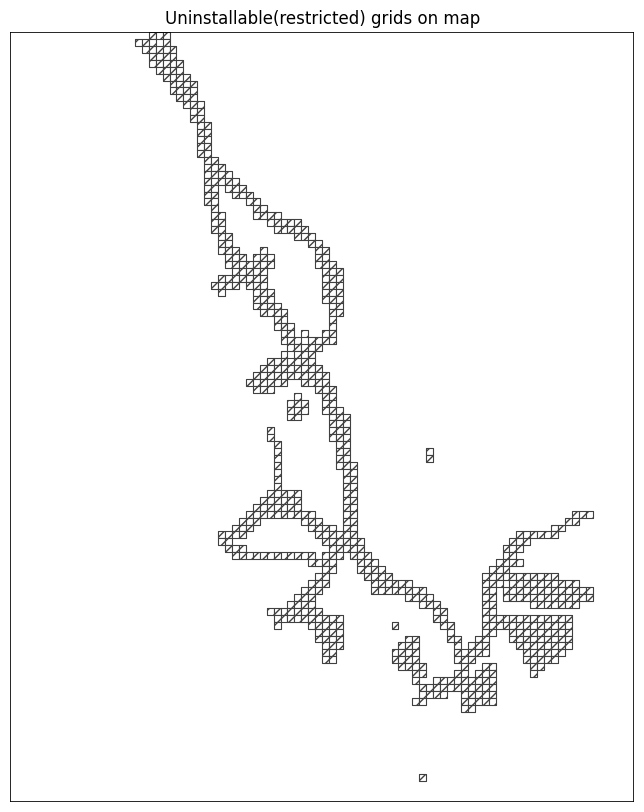

Saved figure: __RESULTS__/_plots/06-11-11-19/restricted__map.png


In [21]:
road_layer = layer_map(map, keep_values=[3])
vis.showMap(map_data=road_layer, title="Uninstallable(restricted) grids on map", cmap="gray", filename="restricted__map", zone_style="restricted")

Jobsite area
<br><sub>The coverage target area for sensor deployment, defined as the union of installable and non-installable regions.</sub>

========== MAP CHECK ==========
Map shape (H,W): 111 x 90
Grid size: 5.0m x 5.0m  |  Cell area: 25.0 m^2
--------------------------------
Total cells: 9,990
Total area : 249,750.00 m^2  |  24.9750 ha  |  0.249750 km^2
--------------------------------
Target value      : [2, 3]
Target area       : 72,550.00 m^2  |  7.2550 ha  |  0.072550 km^2
Target cells      : 2,902  (29.05%)
--------------------------------
Value counts (entire map):
  - value 0: 5,275 (52.80%)
  - value 1: 1,813 (18.15%)
  - value 2: 2,142 (21.44%)
  - value 3: 760 (7.61%)


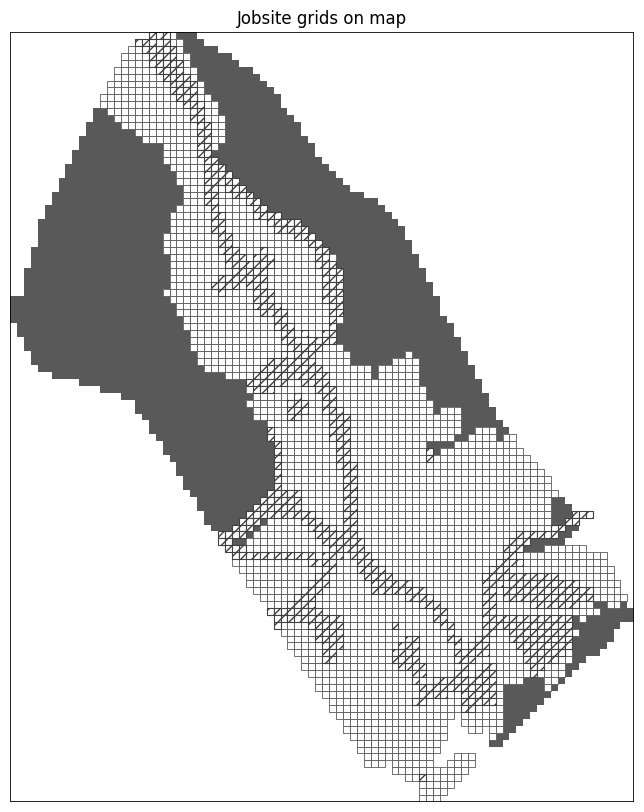

Saved figure: __RESULTS__/_plots/06-11-11-19/map_check.png


In [22]:
jobsite_layer = layer_map(map, keep_values=[2,3])
vis.map_check(map_data=map,title="Jobsite grids on map", return_stats=False, target_values=[2,3], cmap="gray")

### Systematic sensor deployment

In [23]:
#Set sensor coverage radius
COVERAGE = 45

Outermost corner location candidate extraction
<br><sub> Detection of outermost feasible sensor placement candidates within installable regions, since environmental sensing modules must be deployed at the site boundaries to capture extreme conditions. </sub>

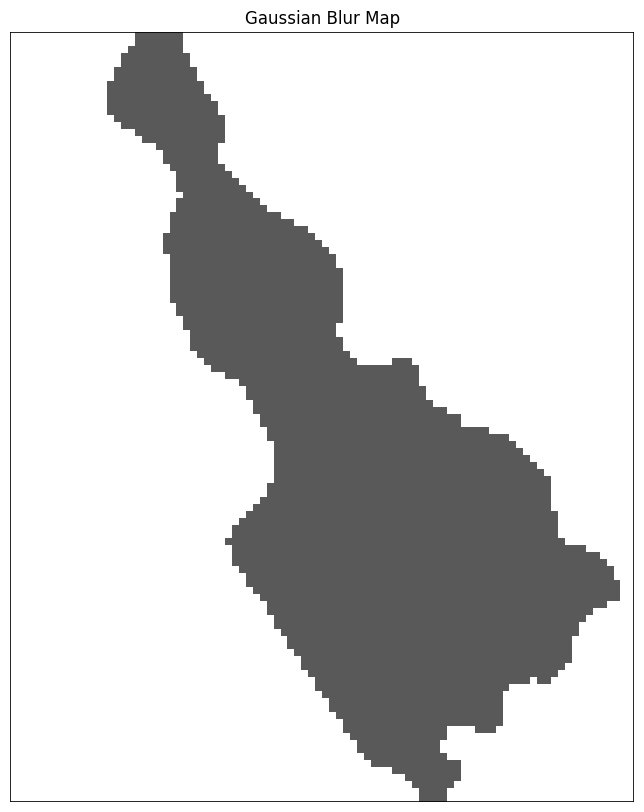

Saved figure: __RESULTS__/_plots/06-11-11-19/gaussian_blur_map.png


In [24]:
from OuterDeployment.HarrisCorner import HarrisCorner

corner_instance = HarrisCorner(jobsite_layer)

blur_map = corner_instance.gaussianBlur(grid=jobsite_layer)
vis.showMap(map_data=blur_map, title="Gaussian Blur Map", cmap='gray', filename="gaussian_blur_map")

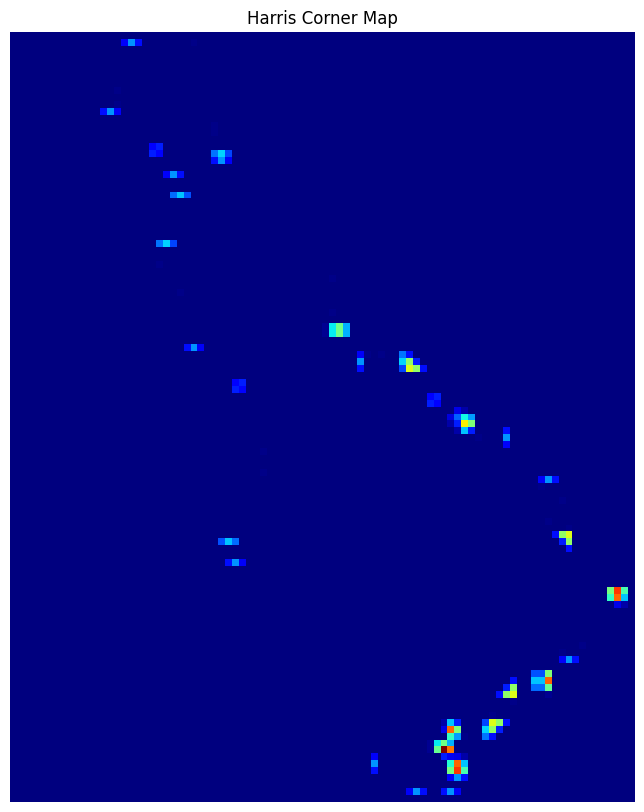

Saved figure: __RESULTS__/_plots/06-11-11-19/harris_corner_map.png


In [25]:
corner_heatmap = corner_instance.harrisCorner(
                                                grid=blur_map,
                                                block_size=3,
                                                ksize=3,
                                                k=0.05
                                                )
vis.showMap(map_data=corner_heatmap, title="Harris Corner Map", cmap="jet", filename="harris_corner_map")

Total outermost sensors : 8


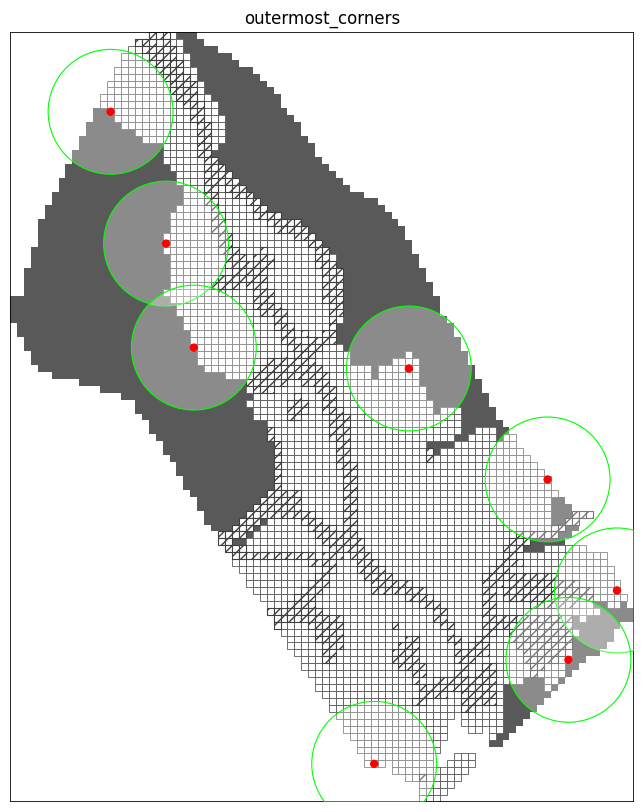

Saved figure: __RESULTS__/_plots/06-11-11-19/corner_sensors.png


In [26]:
corners = corner_instance.LMX(harris_map=corner_heatmap, installable_map=installable_layer, min_dist=9)

print("Total outermost sensors :",len(corners))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=corners, 
    title="outermost_corners",
    cmap="gray",
    filename="corner_sensors"
    )

Outmost corner points: 8


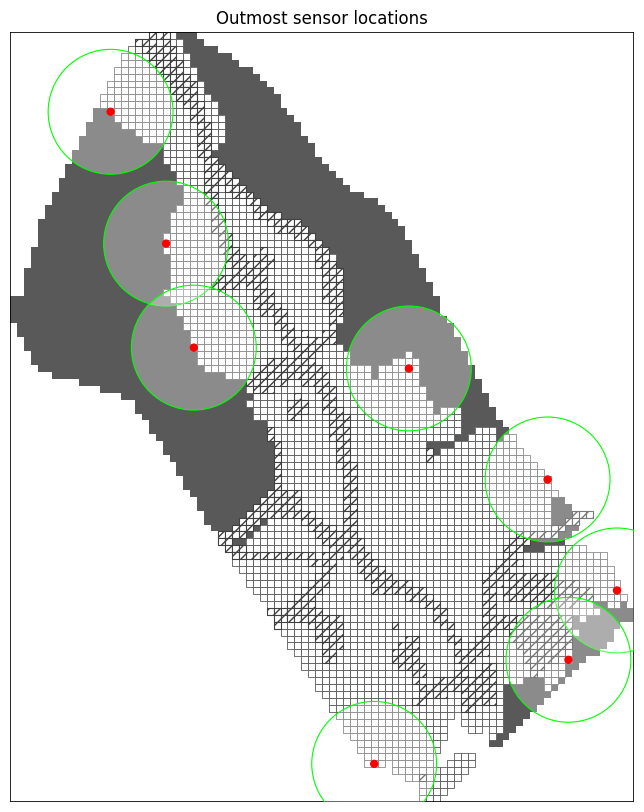

Saved figure: __RESULTS__/_plots/06-11-11-19/corner_sensors.png


In [27]:
corner_layer = HarrisCorner(jobsite_layer)
corner_candidate = corner_layer.run(
    grid=jobsite_layer,                
    installable_layer=installable_layer, 
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(map_data=map, sensor_positions=corner_candidate, title="Outmost sensor locations",radius=COVERAGE, cmap='gray', filename="corner_sensors")

Inner-Deployment Strategy: Genetic Algorithm
<br><sub>Genetic Algorithm is used to optimize the placement of inner sensors, minimizing the number of sensors while ensuring sufficient coverage of the jobsite area. </sub>

In [28]:
from InnerDeployment.GeneticAlgorithm.main import SensorGA

ga = SensorGA(
                installable_map=installable_layer,
                jobsite_map=jobsite_layer,
                coverage=COVERAGE,
                generations=1000,
                corner_positions=corner_candidate,
                initial_size=100,
                selection_size=50,
                child_chromo_size=100,
                init_min_sensors=40,
                init_max_sensors=140,
            )

optimized_result = ga.run(
                    selection_method="elite",
                    mutation_rate=0.7,
                    early_stop=False,
                    early_stop_coverage=90.0,
                    early_stop_patience=10,
                    return_best_only=True
                )

[Profile Gen 001] fitness=0.125s | selection=0.000s | repro=0.261s (crossover=0.000s, mutation=0.000s) | calls: crossover~100, mutation~70.0
               repro_detail: pool_init=0.000s | warmup=0.000s | parallel=0.261s
               fitness_breakdown: ordering=0.000s | prefix=0.000s | score=0.000s | pop=100 

[MP Warmup] pool_init=0.000s | warmup=11.255s
[Gen 001/1000] sensors: (min=13, avg=17.8, max=23) / coverage: 96.90% (target=100.00%) / best_inner=15 (corner=8) / time=0.431s
[Profile Gen 002] fitness=0.051s | selection=0.000s | repro=0.176s (crossover=0.000s, mutation=0.000s) | calls: crossover~100, mutation~70.0
               repro_detail: pool_init=0.000s | warmup=0.000s | parallel=0.176s
               fitness_breakdown: ordering=0.000s | prefix=0.000s | score=0.000s | pop=100 

[Gen 002/1000] sensors: (min=6, avg=14.4, max=20) / coverage: 96.90% (target=100.00%) / best_inner=15 (corner=8) / time=0.273s
[Profile Gen 003] fitness=0.051s | selection=0.000s | repro=0.160s (cro

In [29]:
print("[FINALIZE OUTPUT] ga.best_solution =", ga.best_solution)
print("[FINALIZE OUTPUT] len(ga.best_solution) =", len(ga.best_solution))
print("[FINALIZE OUTPUT] ga.corner_points =", ga.corner_points)
print("[FINALIZE OUTPUT] len(ga.corner_points) =", len(ga.corner_points))

[FINALIZE OUTPUT] ga.best_solution = [(70, 74), (46, 66), (62, 63), (41, 80), (48, 51), (53, 93), (58, 76), (67, 91), (33, 30), (24, 2), (43, 40), (22, 17), (64, 105), (35, 53)]
[FINALIZE OUTPUT] len(ga.best_solution) = 14
[FINALIZE OUTPUT] ga.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(ga.corner_points) = 8


Total number of Sensor : 22


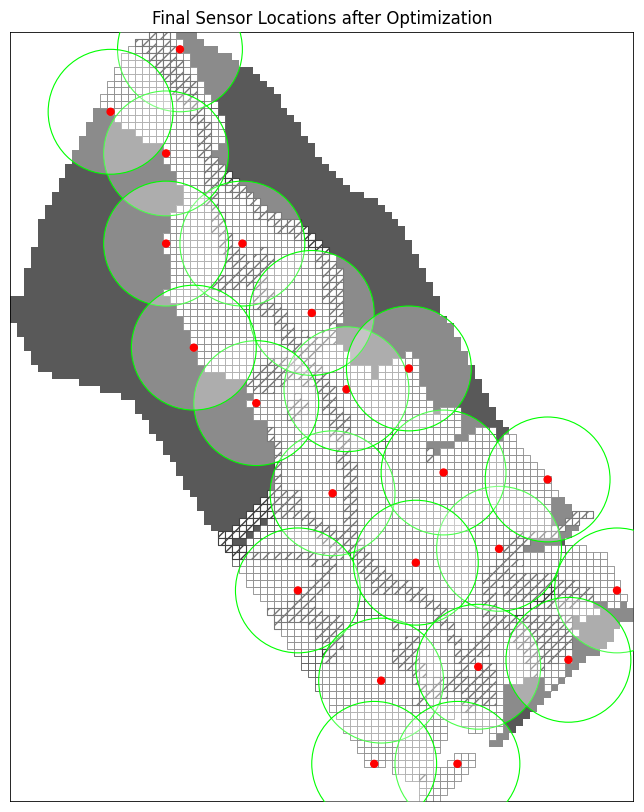

Saved figure: __RESULTS__/_plots/06-11-11-19/final_sensors.png


In [30]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor :", len(final_result))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=final_result,
    title="Final Sensor Locations after Optimization",
    radius=COVERAGE,
    cmap='gray',
    filename="final_sensors"
    )